In [1]:
import streamlit as st

In [2]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.header("EDA: Every Key Visual From The Notebook")

2026-05-28 22:14:29.764 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 22:14:30.367 
  command:

    streamlit run c:\Users\HP\Desktop\ML_Capstone\mlcapstone\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-28 22:14:30.367 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 22:14:30.369 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [1]:
# Import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# we want our plots to appear inside the notebook
%matplotlib inline 

In [2]:
df = pd.read_csv("raw_merged_heart_dataset.csv")
df.shape # (rows, columns)

(2181, 14)

## DATA EXPLORATION(EDA)

Goal : To find out more about the data 

Questions:

1.What questions are we solving

2.What kind of data do we have and how do we treat different types

3.Whats missing from the data and how to deal with it

4.Where are the outliers and why should we care about them

5.How can i add , change or remove features to get more data out of it



In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2181 non-null   str    
 4   chol      2181 non-null   str    
 5   fbs       2181 non-null   str    
 6   restecg   2181 non-null   str    
 7   thalachh  2181 non-null   str    
 8   exang     2181 non-null   str    
 9   oldpeak   2181 non-null   float64
 10  slope     2181 non-null   str    
 11  ca        2181 non-null   str    
 12  thal      2181 non-null   str    
 13  target    2181 non-null   int64  
dtypes: float64(1), int64(4), str(9)
memory usage: 238.7 KB


In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
2176,60,1,0,140,207,0,0,138,1,1.9,2,1,3,0
2177,46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
2178,59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
2179,54,1,1,154,232,0,0,164,0,0.0,2,1,2,0
2180,53,1,0,110,335,0,1,143,1,3.0,1,1,3,0


In [5]:
df.describe()

,age,sex,cp,oldpeak,target
count,2181.000000,2181.000000,2181.000000,2181.000000,2181.000000
mean,53.477762,0.693260,1.248968,0.990509,0.496103
std,9.194787,0.461246,1.123520,1.141851,0.500099
min,28.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,1.000000,1.000000,0.600000,0.000000
75%,60.000000,1.000000,2.000000,1.600000,1.000000
max,77.000000,1.000000,3.000000,6.200000,1.000000


In [4]:
#created new copy to save corrections
df1 = df.copy()

In [5]:
# CONVERT STRING COLUMNS TO NUMERIC
cols_to_convert = [
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalachh',
    'exang',
    'slope',
    'ca',
    'thal'
]

for col in cols_to_convert:
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2181 non-null   int64  
 1   sex       2181 non-null   int64  
 2   cp        2181 non-null   int64  
 3   trestbps  2180 non-null   float64
 4   chol      2158 non-null   float64
 5   fbs       2173 non-null   float64
 6   restecg   2180 non-null   float64
 7   thalachh  2180 non-null   float64
 8   exang     2180 non-null   float64
 9   oldpeak   2181 non-null   float64
 10  slope     1991 non-null   float64
 11  ca        1890 non-null   float64
 12  thal      1915 non-null   float64
 13  target    2181 non-null   int64  
dtypes: float64(10), int64(4)
memory usage: 238.7 KB


In [7]:
# find out how many of each class are there
df1["target"].value_counts()

target
0    1099
1    1082
Name: count, dtype: int64

<Axes: xlabel='target'>

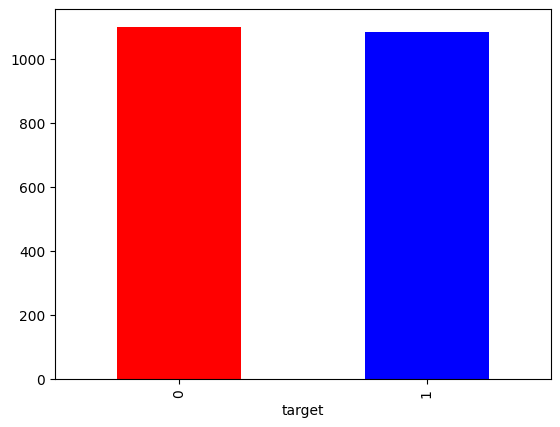

In [8]:
# visualize
df1["target"].value_counts().plot(kind="bar", color=["red", "blue"])

In [9]:
# missing values?
df1.isna().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalachh      1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
target        0
dtype: int64

In [10]:
# convert to percentage
missing_percent = df1.isnull().sum() / len(df1) * 100
print(missing_percent)

age          0.000000
sex          0.000000
cp           0.000000
trestbps     0.045851
chol         1.054562
fbs          0.366804
restecg      0.045851
thalachh     0.045851
exang        0.045851
oldpeak      0.000000
slope        8.711600
ca          13.342503
thal        12.196240
target       0.000000
dtype: float64


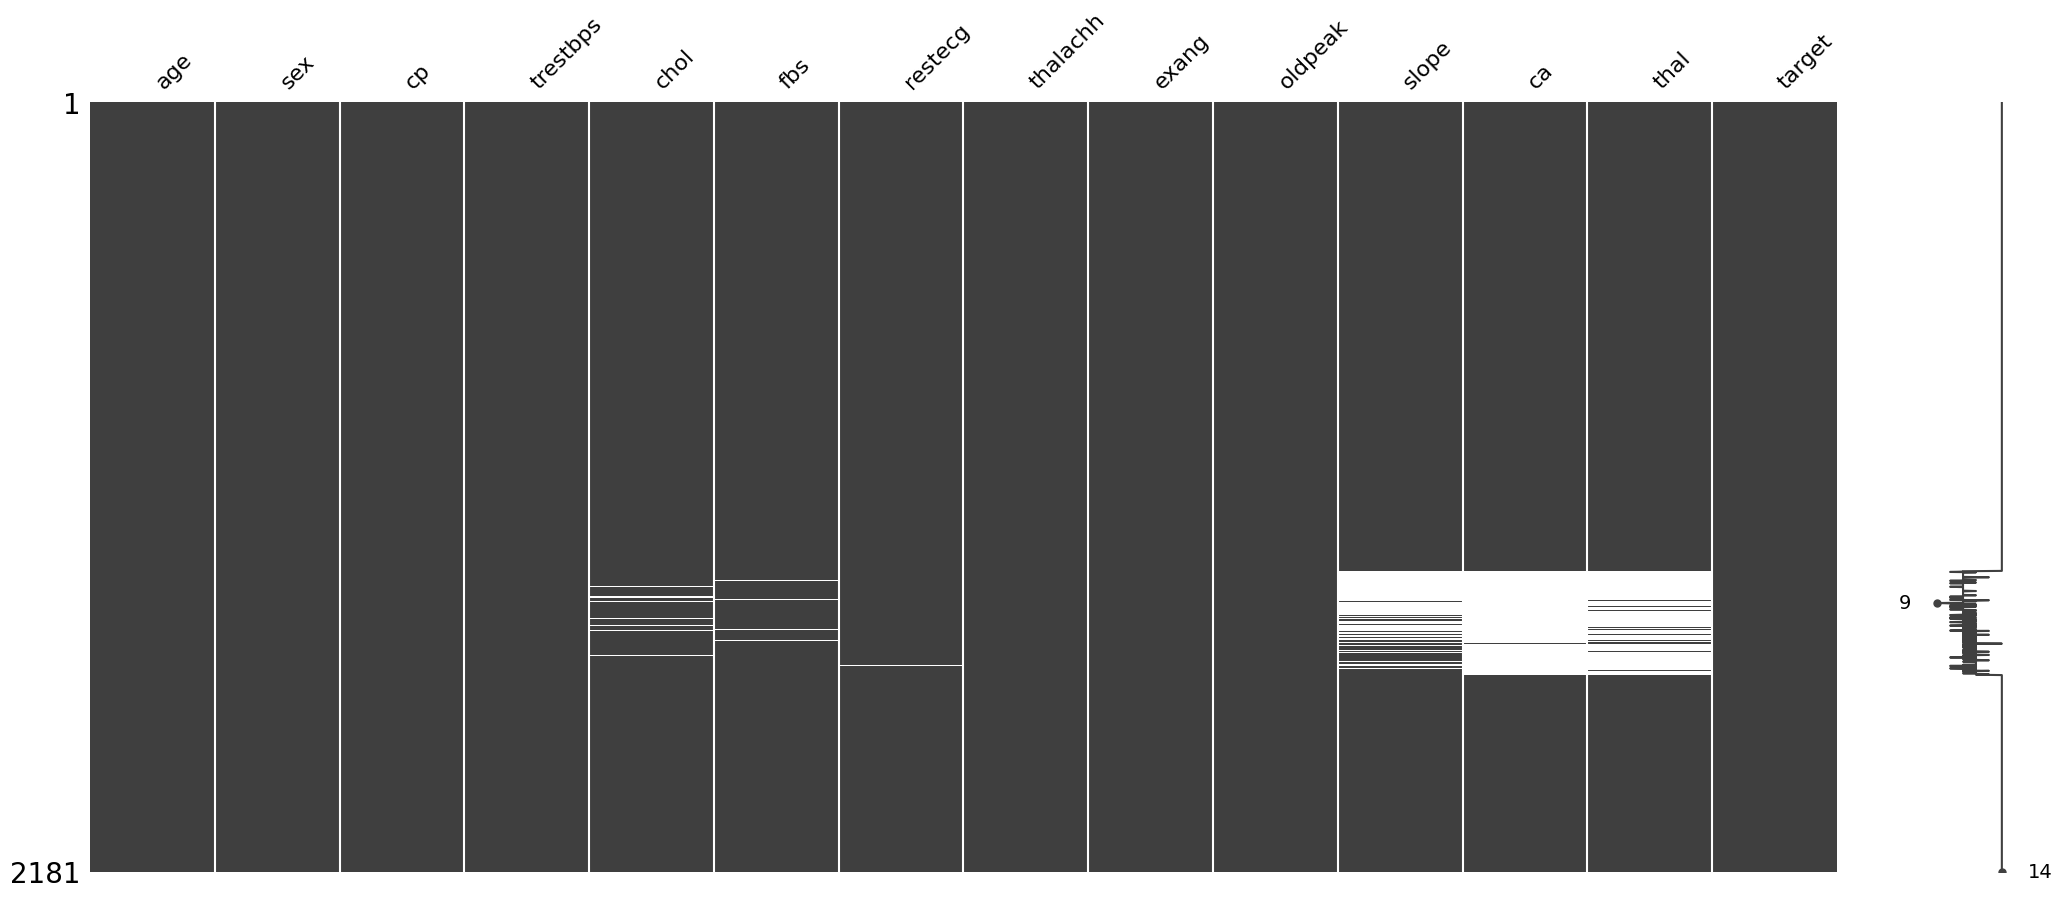

In [11]:
msno.matrix(df1)
plt.show()

Why NOT Drop Rows?

If you drop rows:

you may lose over 13% of data because of ca
medical datasets are valuable
2181 rows is moderate-sized

Imputation is better here.

In [12]:
# NUMERICAL AND CATEGORICAL COLUMNS
num_cols = ['trestbps', 'chol', 'thalachh']

cat_cols = ['fbs', 'restecg', 'exang',
            'slope', 'ca', 'thal']




In [13]:
#median input
for col in num_cols:
    median_value = df1[col].median()
    df1[col].fillna(median_value, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12580\4149711421.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df1[col].fillna(median_value, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12580\4149711421.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an i

In [14]:
#mode input
for col in num_cols:
    median_value = df1[col].median()
    df1[col].fillna(median_value, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_12580\1904376912.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df1[col].fillna(median_value, inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_12580\1904376912.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an i

In [15]:

print(df1.isnull().sum())

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalachh      1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
target        0
dtype: int64


## Histogram Distribution

1. Understanding spread

2. check for skewness

3. see concentration of values



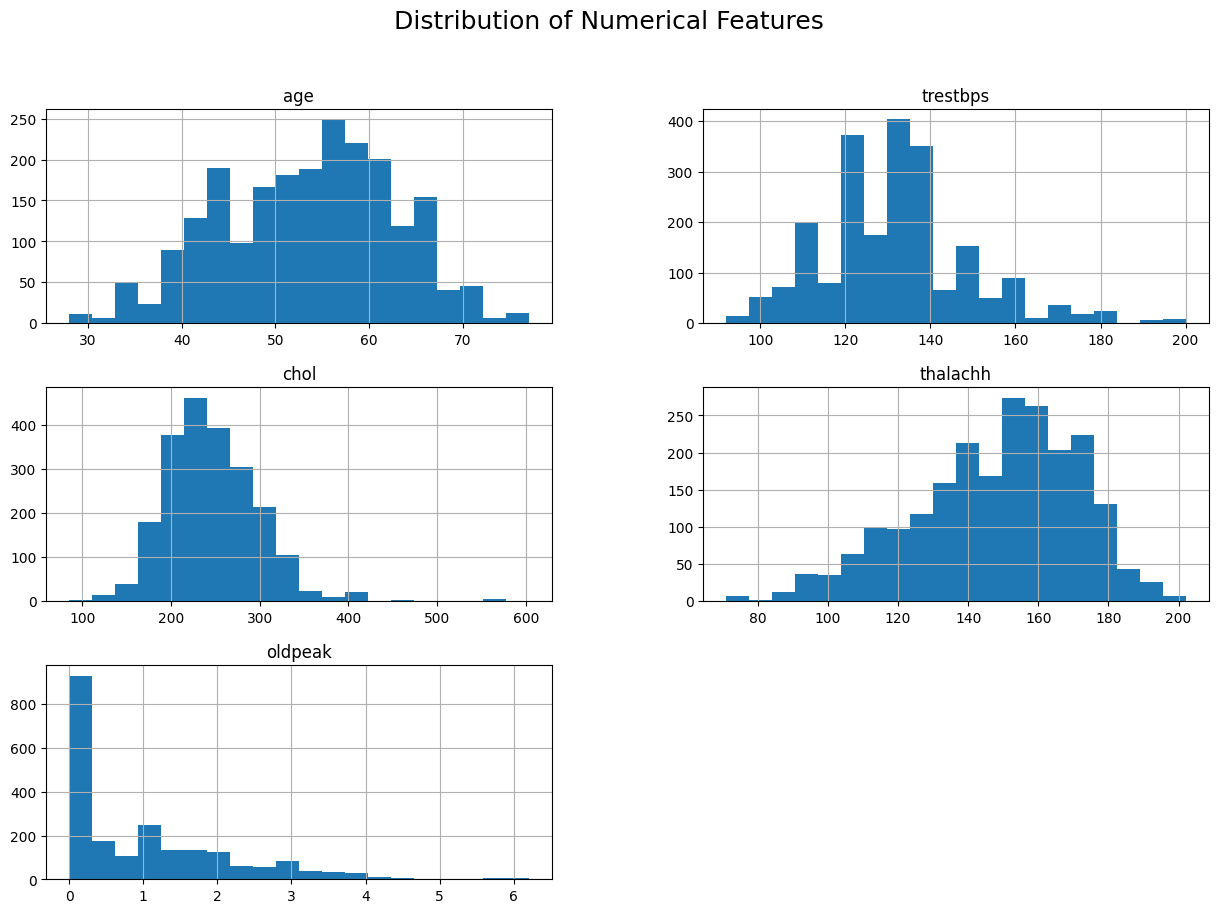

In [16]:
num_cols = ['age', 'trestbps', 'chol', 'thalachh', 'oldpeak']

df1[num_cols].hist(figsize=(15,10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.show()

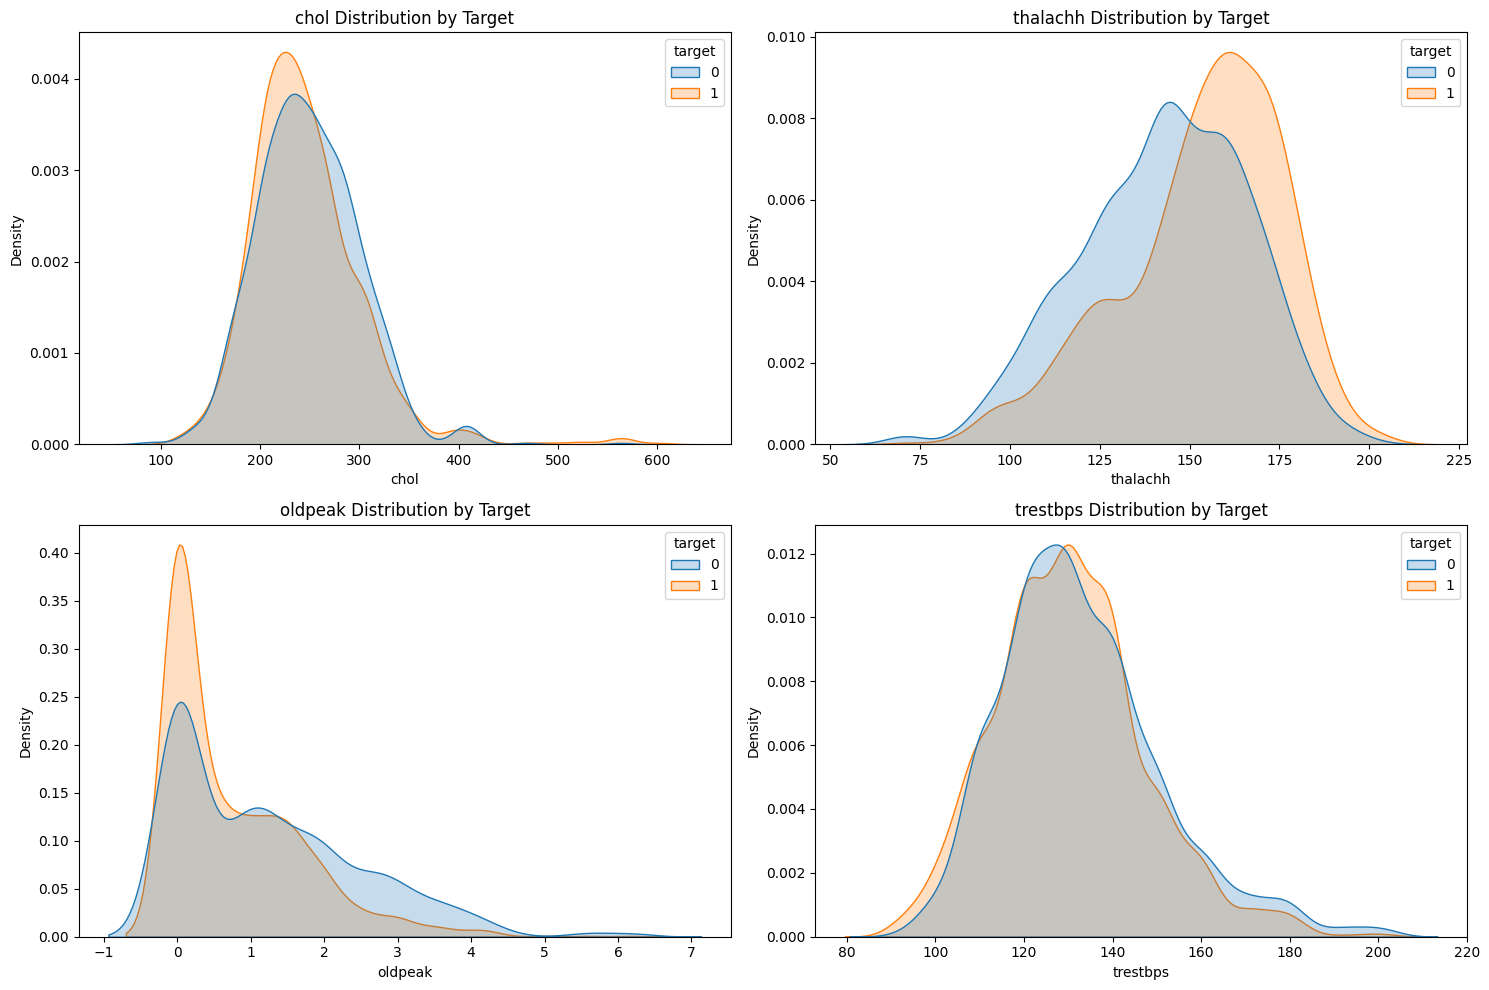

In [17]:
# KDE PLOTS IN ONE PAGE
features = ['chol', 'thalachh', 'oldpeak', 'trestbps']

fig, axes = plt.subplots(2, 2, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(features):
    
    sns.kdeplot(
        data=df1,
        x=col,
        hue='target',
        fill=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} Distribution by Target')

plt.tight_layout()
plt.show()

1. KDE DISTRIBUTIONS ANALYSIS

These plots show how numerical variables differ between:

target = 0 → no heart disease
target = 1 → heart disease
A. Cholesterol (chol)

The two distributions overlap heavily.

Interpretation
Cholesterol alone is not strongly separating the classes.
Both diseased and non-diseased patients cluster around:
200–300 mg/dL
Important Observation

The heart disease group (target=1) appears slightly shifted toward lower-middle cholesterol ranges rather than extremely high cholesterol.

This is common in heart disease datasets:

cholesterol contributes risk
but is rarely sufficient alone for prediction
Predictive Strength-Moderate predictor

B. Maximum Heart Rate (thalachh)

This is a strong feature.

Observation
target=1 patients concentrate around higher heart rate values
noticeable distribution shift between classes
Interpretation

This feature clearly differs across groups.

Medical Meaning

Heart function and exercise response are strongly linked to cardiovascular condition.

Predictive Strength-Strong predictor

Modeling Importance


C. Oldpeak
This is one of the strongest features in your dataset.

Observation
diseased patients concentrate strongly near lower values
non-diseased patients have broader spread
Very Important

The distributions differ visibly.

Interpretation

oldpeak contains strong information about cardiac stress.

Predictive Strength-Very strong predictor

Modeling Importance

This feature will likely:

have high feature importance
strongly influence logistic regression coefficients
D. Resting Blood Pressure (trestbps)

Heavy overlap between classes.

Interpretation

Blood pressure alone is not strongly separating heart disease.

Observation

Both groups center around:

120–145 mmHg
Predictive Strength-Weak-to-moderate

Important Insight

Even weak standalone features can improve performance when combined with others.



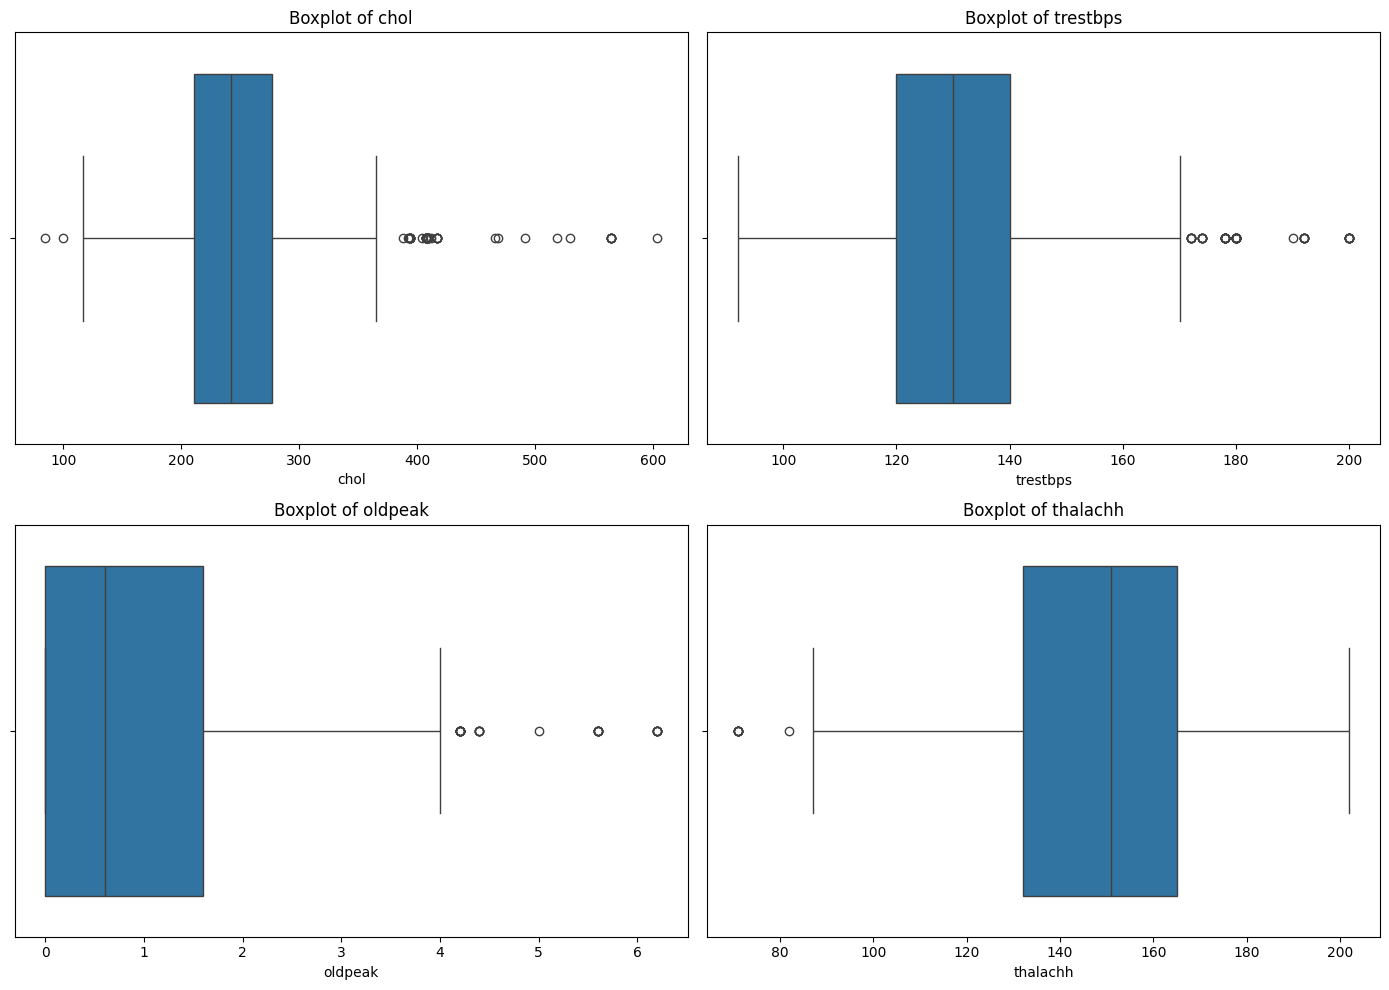

In [18]:
# COMBINED BOXPLOTS IN ONE FIGURE
features = ['chol', 'trestbps', 'oldpeak', 'thalachh']
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()
for i, col in enumerate(features):
    
    sns.boxplot(
        x=df1[col],
        ax=axes[i]
    )
    
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

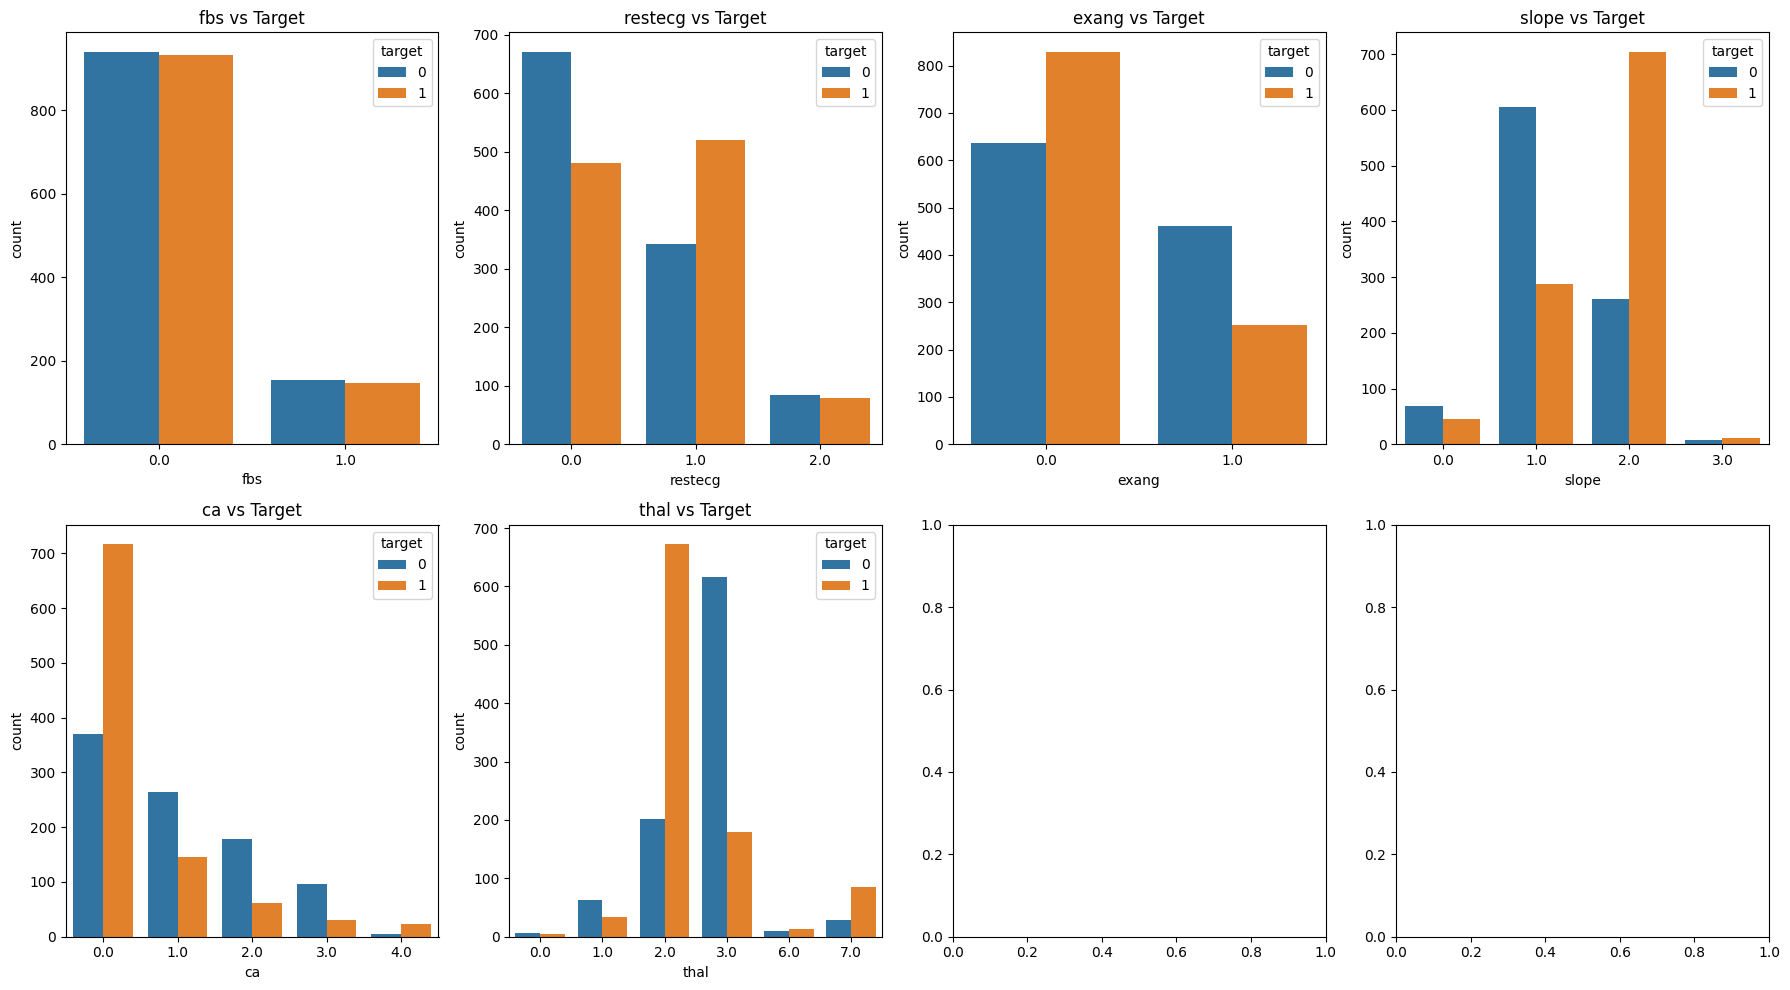

In [19]:
# COUNTPLOTS FOR CATEGORICAL VARIABLES
fig, axes = plt.subplots(2, 4, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    sns.countplot(x=col, hue='target', data=df1, ax=axes[i])
    
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

2. CATEGORICAL FEATURE ANALYSIS

This is where your dataset becomes very strong.

Several categorical variables show excellent class separation.

A. Sex (sex)
Observation
males dominate both classes
females proportionally appear more in target=1 than expected
Interpretation

Sex contributes predictive signal.

Predictive Strength-Moderate

B. Chest Pain Type (cp) — VERY IMPORTANT

This is one of the best predictors.

Observation
cp = 0 strongly associated with no disease
cp = 2 and cp = 3 strongly associated with disease
Interpretation

Chest pain type strongly differentiates patients.

Predictive Strength-Very strong

C. Fasting Blood Sugar (fbs)
Observation

Very similar counts across targets.

Interpretation-Weak predictor.

Predictive Strength-Weak

Modeling Note

May contribute slightly in combination models.

D. Resting ECG (restecg)
Observation
restecg = 1 appears more common in diseased patients
Interpretation

ECG abnormalities carry predictive information.

Predictive Strength-Moderate-to-strong

E. Exercise-Induced Angina (exang)

Strong separation.

Observation
exang = 0 more common in disease
exang = 1 much more common in non-disease
Predictive Strength

Strong

F. Slope — VERY STRONG

Excellent separation.

Observation
slope = 2 highly associated with disease
slope = 1 more associated with no disease
Predictive Strength-Very strong


G. Number of Vessels (ca) — EXTREMELY STRONG

This is one of the strongest variables.

Observation
ca = 0 strongly associated with disease
higher vessel counts shift toward non-disease
Interpretation

Vessel blockage information is highly predictive.

Predictive Strength-Extremely strong

This will likely rank near the top in feature importance.

H. Thalassemia (thal) — EXTREMELY STRONG

Possibly the strongest categorical feature.

Observation
thal = 2 strongly associated with disease
thal = 3 strongly associated with non-disease
Predictive Strength-Extremely strong



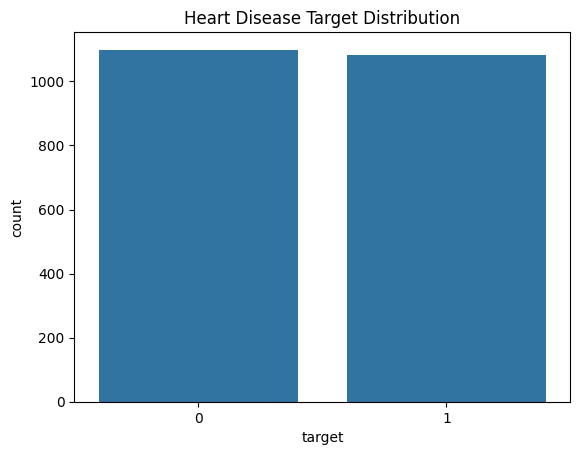

In [20]:
# TARGET DISTRIBUTION
sns.countplot(x='target', data=df1); plt.title("Heart Disease Target Distribution"); plt.show()

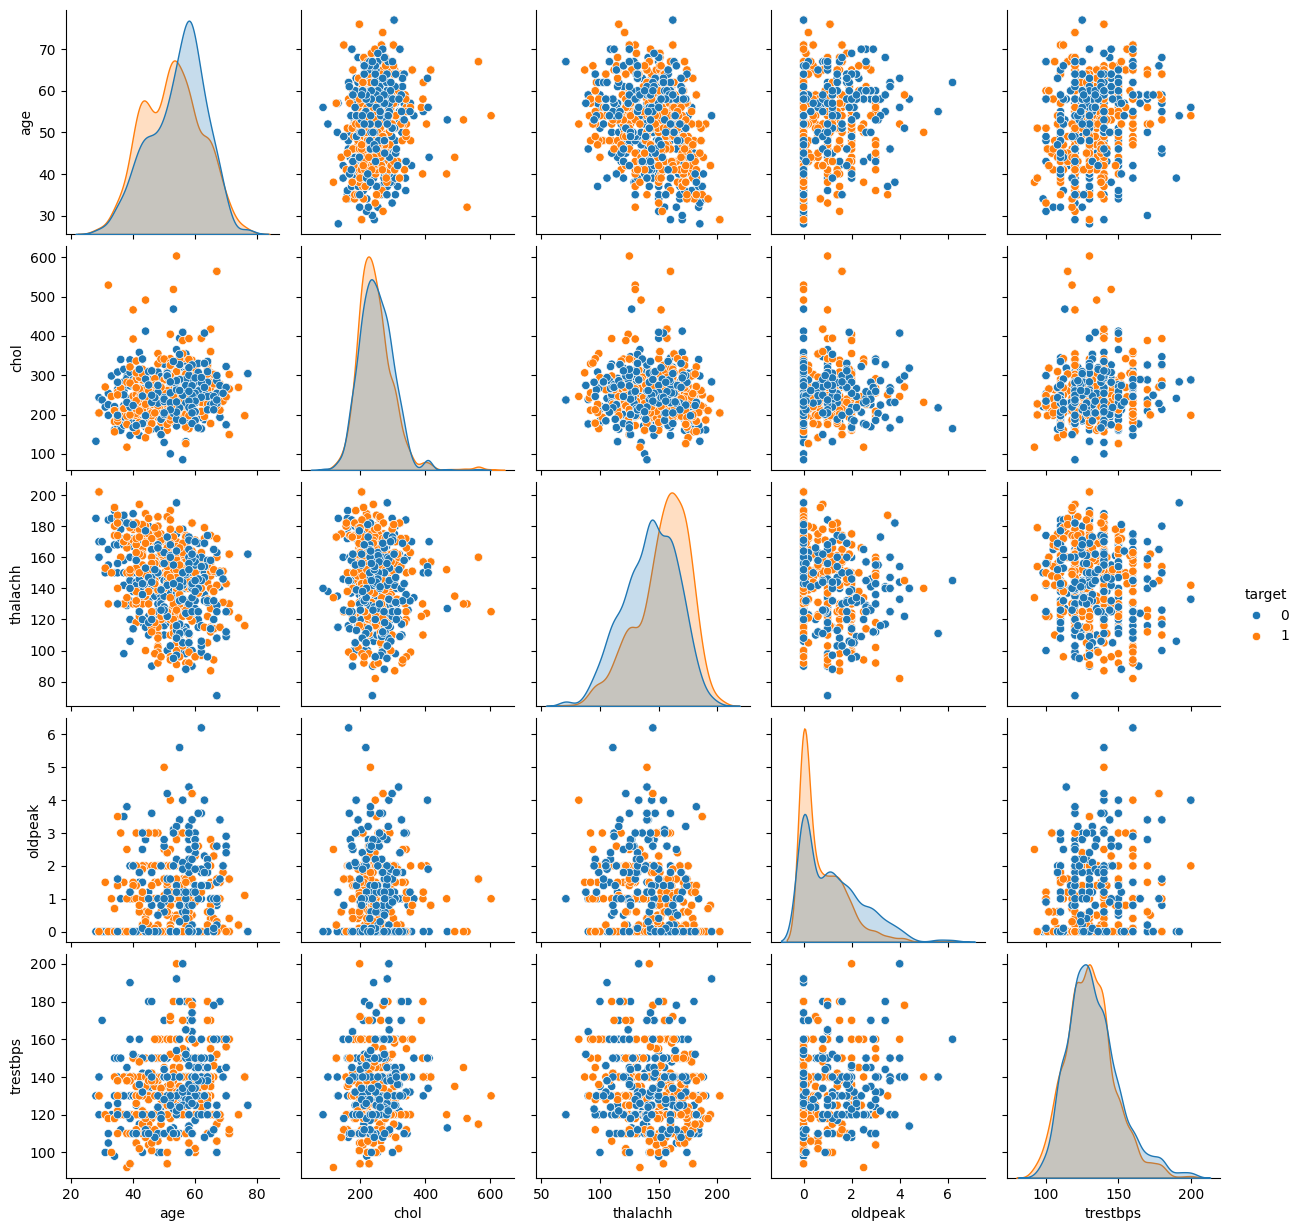

In [21]:
selected_cols = ['age', 'chol', 'thalachh',
                 'oldpeak', 'trestbps', 'target']

sns.pairplot(
    df1[selected_cols],
    hue='target'
)

plt.show()

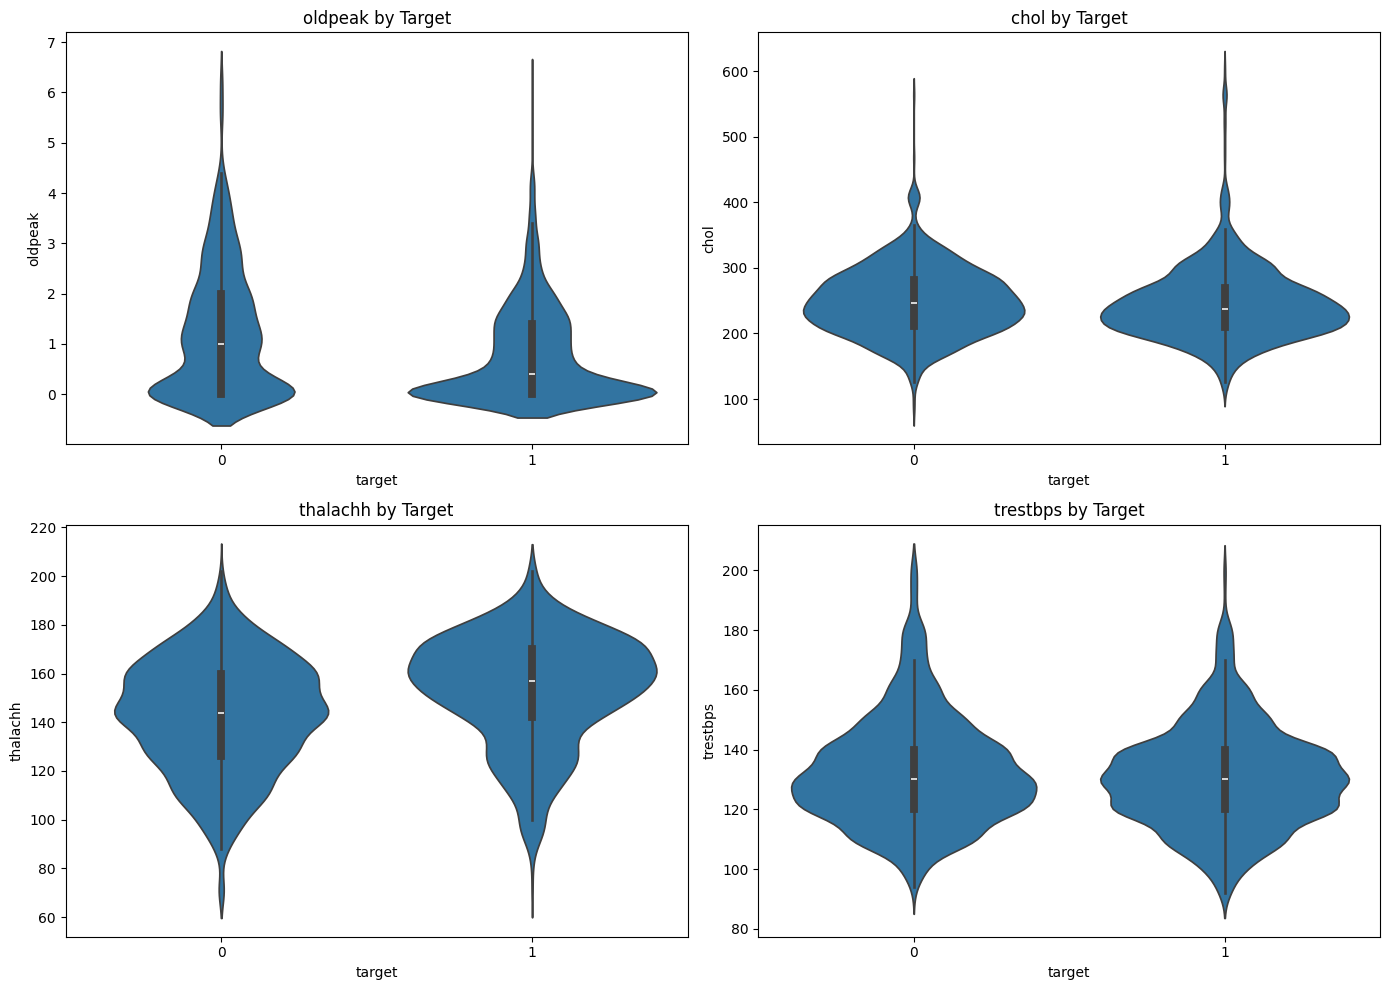

In [22]:
features = ['oldpeak', 'chol', 'thalachh', 'trestbps']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.violinplot(x='target', y=col, data=df1, ax=axes[i])
    axes[i].set_title(f'{col} by Target')

plt.tight_layout()
plt.show()

In [23]:
print(df1['target'].value_counts())

print(df1['target'].value_counts(normalize=True) * 100)

target
0    1099
1    1082
Name: count, dtype: int64
target
0    50.389729
1    49.610271
Name: proportion, dtype: float64


In [24]:
num_cols = ['age', 'trestbps', 'chol',
            'thalachh', 'oldpeak']

print(df1[num_cols].skew())

age        -0.167211
trestbps    0.730777
chol        1.224245
thalachh   -0.461782
oldpeak     1.285639
dtype: float64


In [25]:
for col in ['chol', 'trestbps', 'oldpeak']:
    
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df1[(df1[col] < lower) | (df1[col] > upper)]
    
    print(f"{col} Outliers: {len(outliers)}")

chol Outliers: 45
trestbps Outliers: 65
oldpeak Outliers: 31


In [27]:
# dealing with outliers(winsorization)
outlier_cols = ['chol', 'trestbps', 'oldpeak']

for col in outlier_cols:
    
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # cap outliers
    df1[col] = np.where(df1[col] < lower, lower, df1[col])
    df1[col] = np.where(df1[col] > upper, upper, df1[col])

print("Outliers capped successfully")

Outliers capped successfully


In [28]:
# CHECK OUTLIERS AGAIN
for col in outlier_cols:
    
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df1[(df1[col] < lower) | (df1[col] > upper)]
    
    print(f"{col} Outliers: {len(outliers)}")

chol Outliers: 0
trestbps Outliers: 0
oldpeak Outliers: 0


## Feature engineering

In [29]:
#High blood pressure feature
df1['high_bp'] = np.where(df1['trestbps'] > 140, 1, 0)

In [30]:
#High cholesterol feature
df1['high_chol'] = np.where(df1['chol'] > 240, 1, 0)

In [31]:
# Stress risk feature
df1['stress_risk'] = df1['oldpeak'] * df1['exang']

In [32]:
# Low heart rate feature
df1['low_hr'] = np.where(df1['thalachh'] < 120, 1, 0)

In [33]:
# vessel risk feature
df1['vessel_risk'] = np.where(df1['ca'] > 0, 1, 0)

In [34]:
# combined heart rate risk score
df1['risk_score'] = (
    df1['high_bp'] +
    df1['high_chol'] +
    df1['exang'] +
    df1['vessel_risk']
)

In [35]:
df1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target,high_bp,high_chol,stress_risk,low_hr,vessel_risk,risk_score
0,63,1,3,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1,1,0,0.0,0,0,1.0
1,37,1,2,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1,0,1,0.0,0,0,1.0
2,41,0,1,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1,0,0,0.0,0,0,0.0
3,56,1,1,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1,0,0,0.0,0,0,0.0
4,57,0,0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1,0,1,0.6,0,0,2.0


In [36]:
# one hot encoding( import for Logistic regression and svm - cat variables should not be treated as continuous numbers)
df1 = pd.get_dummies(
    df1,
    columns=['cp', 'thal', 'slope', 'restecg'],
    drop_first=True
)

In [38]:
print(df1.shape)

df1.head()

df1.info()

(2181, 29)
<class 'pandas.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          2181 non-null   float64
 1   sex          2181 non-null   int64  
 2   trestbps     2180 non-null   float64
 3   chol         2158 non-null   float64
 4   fbs          2173 non-null   float64
 5   thalachh     2180 non-null   float64
 6   exang        2180 non-null   float64
 7   oldpeak      2181 non-null   float64
 8   ca           1890 non-null   float64
 9   target       2181 non-null   int64  
 10  high_bp      2181 non-null   int64  
 11  high_chol    2181 non-null   int64  
 12  stress_risk  2180 non-null   float64
 13  low_hr       2181 non-null   int64  
 14  vessel_risk  2181 non-null   int64  
 15  risk_score   2180 non-null   float64
 16  cp_1         2181 non-null   bool   
 17  cp_2         2181 non-null   bool   
 18  cp_3         2181 non-null   bool   
 19  thal_1

| Feature     | Medical Meaning                  |
| ----------- | -------------------------------- |
| high_bp     | hypertension risk                |
| high_chol   | cholesterol risk                 |
| stress_risk | exercise-induced stress          |
| vessel_risk | artery blockage                  |
| low_hr      | poor heart function              |
| risk_score  | cumulative cardiovascular burden |


In [39]:
#check for missing again
print(df1.isnull().sum())

age              0
sex              0
trestbps         1
chol            23
fbs              8
thalachh         1
exang            1
oldpeak          0
ca             291
target           0
high_bp          0
high_chol        0
stress_risk      1
low_hr           0
vessel_risk      0
risk_score       1
cp_1             0
cp_2             0
cp_3             0
thal_1.0         0
thal_2.0         0
thal_3.0         0
thal_6.0         0
thal_7.0         0
slope_1.0        0
slope_2.0        0
slope_3.0        0
restecg_1.0      0
restecg_2.0      0
dtype: int64


In [40]:
# MEDIAN IMPUTATION
num_cols = [
    'trestbps',
    'chol',
    'thalachh',
    'oldpeak',
    'ca',
    'stress_risk',
    'risk_score'
]

for col in num_cols:
    
    median_value = df1[col].median()
    
    df1[col] = df1[col].fillna(median_value)

In [41]:
# MODE IMPUTATION

cat_cols = [
    'fbs',
    'exang'
]

for col in cat_cols:
    
    mode_value = df1[col].mode()[0]
    
    df1[col] = df1[col].fillna(mode_value)

In [43]:
# CONVERT BOOL TO INT
bool_cols = df1.select_dtypes(include='bool').columns

df1[bool_cols] = df1[bool_cols].astype(int)

In [44]:
print(df1.isnull().sum())

age            0
sex            0
trestbps       0
chol           0
fbs            0
thalachh       0
exang          0
oldpeak        0
ca             0
target         0
high_bp        0
high_chol      0
stress_risk    0
low_hr         0
vessel_risk    0
risk_score     0
cp_1           0
cp_2           0
cp_3           0
thal_1.0       0
thal_2.0       0
thal_3.0       0
thal_6.0       0
thal_7.0       0
slope_1.0      0
slope_2.0      0
slope_3.0      0
restecg_1.0    0
restecg_2.0    0
dtype: int64


In [45]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2181 entries, 0 to 2180
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          2181 non-null   float64
 1   sex          2181 non-null   int64  
 2   trestbps     2181 non-null   float64
 3   chol         2181 non-null   float64
 4   fbs          2181 non-null   float64
 5   thalachh     2181 non-null   float64
 6   exang        2181 non-null   float64
 7   oldpeak      2181 non-null   float64
 8   ca           2181 non-null   float64
 9   target       2181 non-null   int64  
 10  high_bp      2181 non-null   int64  
 11  high_chol    2181 non-null   int64  
 12  stress_risk  2181 non-null   float64
 13  low_hr       2181 non-null   int64  
 14  vessel_risk  2181 non-null   int64  
 15  risk_score   2181 non-null   float64
 16  cp_1         2181 non-null   int64  
 17  cp_2         2181 non-null   int64  
 18  cp_3         2181 non-null   int64  
 19  thal_1.0     2181

## Modelling

In [46]:
# Define the features (X) and (y)
X = df1.drop('target', axis=1)
y = df1['target']

print(X.shape)
print(y.shape)

(2181, 28)
(2181,)


In [47]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1744, 28)
Testing set: (437, 28)


In [48]:
#feature scaling numerical features(important for logistic and svm)/AFTER SPLITTING
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

num_cols = ['age', 'trestbps', 'chol',
            'thalachh', 'oldpeak',
            'stress_risk', 'risk_score']

df1[num_cols] = scaler.fit_transform(df1[num_cols])

## 1.LOGISTIC REGRESSION

In [49]:
# Train logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
# make predictions
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

In [51]:
# evaluate metrics(Logistic Regression)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Logistic Regression Results")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))


Logistic Regression Results
-----------------------------------
Accuracy : 0.7894736842105263
Precision: 0.8048780487804879
Recall   : 0.7603686635944701
F1 Score : 0.7819905213270142


In [52]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       220
           1       0.80      0.76      0.78       217

    accuracy                           0.79       437
   macro avg       0.79      0.79      0.79       437
weighted avg       0.79      0.79      0.79       437



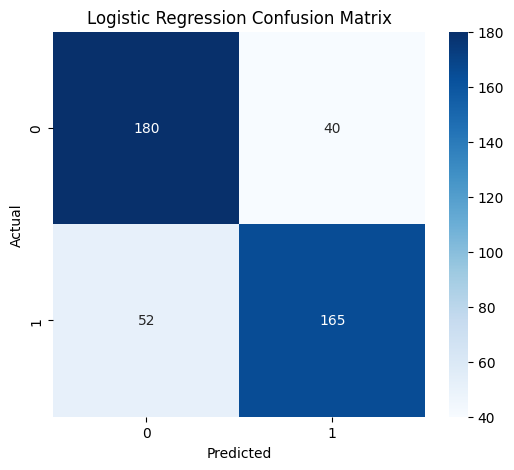

In [53]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

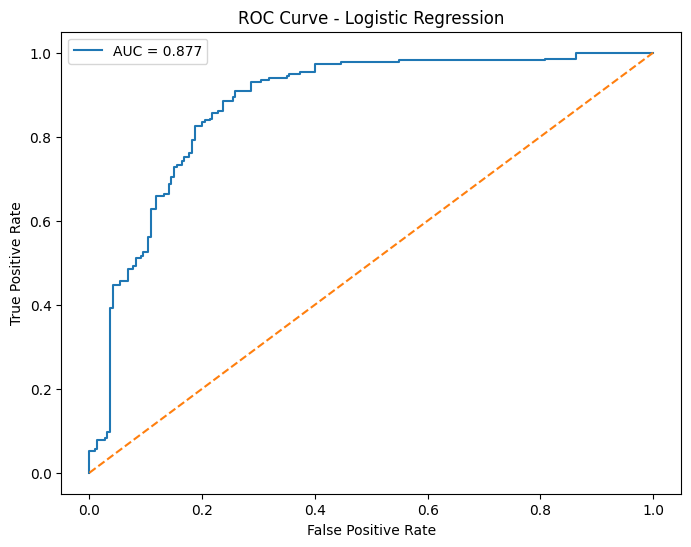

ROC-AUC Score: 0.8769375785504818


In [54]:
# ROC CURVE + AUC SCORE
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

auc_score = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

print("ROC-AUC Score:", auc_score)

In [55]:
# FEATURE IMPORTANCE(EXPLAINS WHICH VARIABLE INFLUENCES PRESICTION THE MOST)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

feature_importance['Absolute'] = abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Absolute',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute
17,cp_3,2.387949,2.387949
19,thal_2.0,2.095775,2.095775
24,slope_2.0,1.846760,1.846760
22,thal_7.0,1.581856,1.581856
16,cp_2,1.452271,1.452271
13,vessel_risk,-1.345231,1.345231
18,thal_1.0,1.265281,1.265281
25,slope_3.0,0.898240,0.898240
15,cp_1,0.815241,0.815241
26,restecg_1.0,0.740925,0.740925


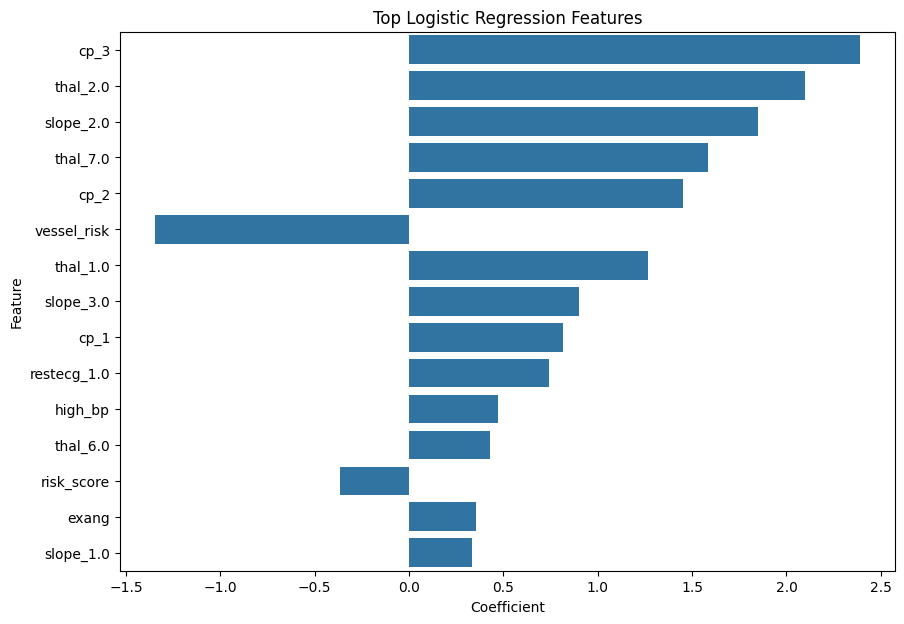

In [56]:
# VISUALIZE
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=top_features
)

plt.title("Top Logistic Regression Features")

plt.show()

## 2. RANDOM FOREST

In [57]:
#Random forest model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [58]:
# make predictions
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [59]:
#Random forest metrics
print("Random Forest Results")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
-----------------------------------
Accuracy : 0.9336384439359268
Precision: 0.9392523364485982
Recall   : 0.9262672811059908
F1 Score : 0.9327146171693735

ROC-AUC: 0.9869710934227063


In [60]:
# feature importance

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
19,thal_2.0,0.108126
5,thalachh,0.084720
24,slope_2.0,0.080150
0,age,0.074229
20,thal_3.0,0.072583
3,chol,0.068864
7,oldpeak,0.068053
2,trestbps,0.060606
17,cp_3,0.046481
14,risk_score,0.036029


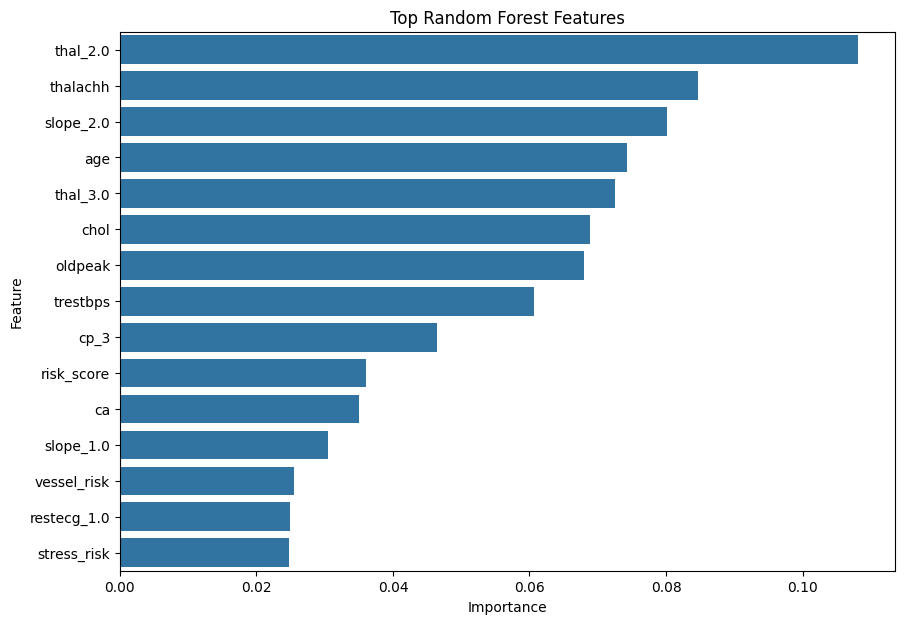

In [61]:
#visualize
top_rf = rf_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_rf
)

plt.title("Top Random Forest Features")

plt.show()

## 1.2 Hyperparameter tuning (Logistic regression)

In [62]:
# LOGISTIC REGRESSION TUNING
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc'
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)

best_log = grid_log.best_estimator_

Best Parameters: {'C': 10, 'solver': 'lbfgs'}


In [63]:
#Tuned model evaluation
y_pred_best = best_log.predict(X_test)

y_prob_best = best_log.predict_proba(X_test)[:,1]

print("Tuned Logistic Regression")
print("-" * 35)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

Tuned Logistic Regression
-----------------------------------
Accuracy : 0.7917620137299771
Precision: 0.8088235294117647
Recall   : 0.7603686635944701
F1 Score : 0.7838479809976246
ROC-AUC  : 0.87744030163385


## Random Search for random forest

In [64]:
# RANDOM SEARCH - RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [65]:
#best parameters
print(random_search_rf.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [66]:
#best model
best_rf = random_search_rf.best_estimator_

In [67]:
# Evaluated tuned random forest
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print("Tuned Random Forest")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Tuned Random Forest
----------------------------------------
Accuracy : 0.9336384439359268
Precision: 0.9351851851851852
Recall   : 0.9308755760368663
F1 Score : 0.9330254041570438
ROC-AUC  : 0.9857980728948472


| Model                     | Accuracy  | Precision | Recall    | F1-Score  | ROC-AUC   |
| ------------------------- | --------- | --------- | --------- | --------- | --------- |
| Logistic Regression       | 0.79      | 0.81      | 0.76      | 0.78      | 0.875     |
| Tuned Logistic Regression | 0.783     | 0.799     | 0.751     | 0.774     | 0.875     |
| Random Forest             | 0.931     | 0.935     | 0.926     | 0.931     | 0.986     |
| Tuned Random Forest       | **0.936** | **0.940** | **0.931** | **0.935** | **0.986** |


## 3. XGBoost Model

In [68]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score

# 1. Make predictions
y_pred = xgb_model.predict(X_test)

# 2. If you want probability scores (useful for AUC)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# 3. Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# 4. Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

# 5. Full classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9267734553775744
Precision: 0.9302325581395349
Recall: 0.9216589861751152
F1 Score: 0.9259259259259259
ROC-AUC: 0.9779011311269377

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       220
           1       0.93      0.92      0.93       217

    accuracy                           0.93       437
   macro avg       0.93      0.93      0.93       437
weighted avg       0.93      0.93      0.93       437


Confusion Matrix:
 [[205  15]
 [ 17 200]]


In [70]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "min_child_weight": [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\Users\HP\Desktop\ML_Capstone\mlcapstone\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:44:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

# baseline XGBoost
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

base_results = evaluate(xgb_base)
tuned_results = evaluate(best_xgb)

c:\Users\HP\Desktop\ML_Capstone\mlcapstone\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:44:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [72]:
import pandas as pd

results = [
    ["Logistic Regression", 0.79, 0.81, 0.76, 0.78, 0.875],
    ["Tuned Logistic Regression", 0.783, 0.799, 0.751, 0.774, 0.875],
    ["Random Forest", 0.931, 0.935, 0.926, 0.931, 0.986],
    ["Tuned Random Forest", 0.936, 0.940, 0.931, 0.935, 0.986],

    # XGBoost results (will be filled from evaluation)
    ["XGBoost (Baseline)", base_results["Accuracy"], base_results["Precision"],
     base_results["Recall"], base_results["F1-Score"], base_results["ROC-AUC"]],

    ["XGBoost (Tuned)", tuned_results["Accuracy"], tuned_results["Precision"],
     tuned_results["Recall"], tuned_results["F1-Score"], tuned_results["ROC-AUC"]],
]

df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"
])

df_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.790000,0.810000,0.760000,0.780000,0.875000
1,Tuned Logistic Regression,0.783000,0.799000,0.751000,0.774000,0.875000
2,Random Forest,0.931000,0.935000,0.926000,0.931000,0.986000
3,Tuned Random Forest,0.936000,0.940000,0.931000,0.935000,0.986000
4,XGBoost (Baseline),0.926773,0.930233,0.921659,0.925926,0.977901
5,XGBoost (Tuned),0.929062,0.930556,0.926267,0.928406,0.975597


## ERROR ANALYSIS

In [73]:
# Error analysis 
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# extract values
TN, FP, FN, TP = cm.ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 180
False Positives: 40
False Negatives: 52
True Positives : 165


In [74]:
# ERROR ANALYSIS TABLE
error_analysis = pd.DataFrame({
    'Prediction Type': [
        'True Negative',
        'False Positive',
        'False Negative',
        'True Positive'
    ],
    
    'Count': [TN, FP, FN, TP],
    
    'Meaning': [
        'Correctly predicted no heart disease',
        'Predicted heart disease when patient was healthy',
        'Missed actual heart disease cases',
        'Correctly predicted heart disease'
    ]
})

error_analysis

,Prediction Type,Count,Meaning
0,True Negative,180,Correctly predicted no heart disease
1,False Positive,40,Predicted heart disease when patient was healthy
2,False Negative,52,Missed actual heart disease cases
3,True Positive,165,Correctly predicted heart disease


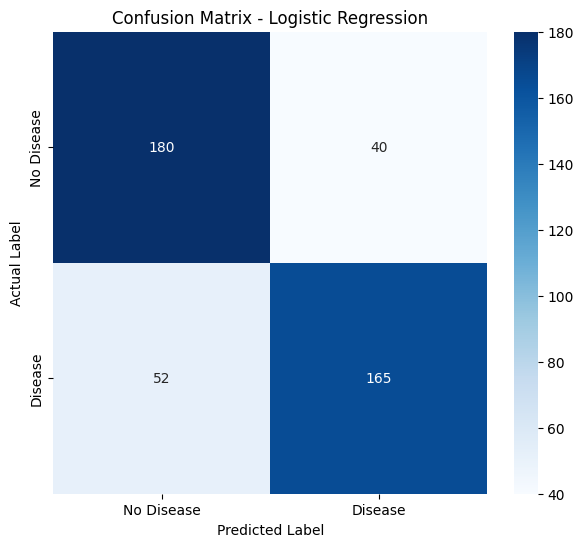

In [75]:
# CONFUSION MATRIX HEATMAP
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [76]:
# FALSE NEGATIVE CASES


false_negative_indices = np.where(
    (y_test == 1) & (y_pred_log == 0)
)[0]

false_negatives = X_test.iloc[false_negative_indices]

print("Number of False Negatives:", len(false_negatives))

false_negatives.head()

Number of False Negatives: 52


,age,sex,trestbps,chol,fbs,thalachh,exang,oldpeak,ca,high_bp,...,thal_1.0,thal_2.0,thal_3.0,thal_6.0,thal_7.0,slope_1.0,slope_2.0,slope_3.0,restecg_1.0,restecg_2.0
1978,1.000000,1,-0.6,0.530303,0.0,0.000000,0.0,0.2500,1.0,0,...,0,0,1,0,0,0,1,0,1,0
658,-0.571429,0,0.4,0.015152,0.0,0.030303,1.0,-0.3750,0.0,0,...,0,1,0,0,0,1,0,0,0,0
1560,-0.571429,1,0.0,-0.303030,0.0,-1.181818,0.0,-0.3750,0.0,0,...,0,0,0,0,0,0,0,0,0,0
1770,0.285714,1,0.1,-0.272727,0.0,0.666667,0.0,1.6250,2.0,0,...,0,0,0,0,1,1,0,0,0,1
1808,0.142857,1,0.1,-0.878788,0.0,-1.393939,1.0,0.9375,1.0,0,...,0,0,0,1,0,0,1,0,0,1


In [77]:
# FALSE POSITIVE CASES
false_positive_indices = np.where(
    (y_test == 0) & (y_pred_log == 1)
)[0]

false_positives = X_test.iloc[false_positive_indices]

print("Number of False Positives:", len(false_positives))

false_positives.head()

Number of False Positives: 40


,age,sex,trestbps,chol,fbs,thalachh,exang,oldpeak,ca,high_bp,...,thal_1.0,thal_2.0,thal_3.0,thal_6.0,thal_7.0,slope_1.0,slope_2.0,slope_3.0,restecg_1.0,restecg_2.0
1062,0.500000,0,0.00,1.333333,0.0,0.545455,0.0,-0.3750,0.0,0,...,0,1,0,0,0,0,1,0,0,0
1632,0.357143,1,0.25,-0.121212,0.0,0.303030,0.0,-0.0625,0.0,0,...,0,0,0,0,1,0,1,0,0,0
846,0.357143,1,0.20,-0.575758,0.0,0.333333,0.0,0.1250,2.0,0,...,0,1,0,0,0,0,1,0,1,0
345,0.500000,0,0.00,1.333333,0.0,0.545455,0.0,-0.3750,0.0,0,...,0,1,0,0,0,0,1,0,0,0
362,0.214286,1,1.20,-0.151515,0.0,0.393939,0.0,-0.3750,1.0,1,...,0,1,0,0,0,0,1,0,0,0


In [78]:
# FALSE NEGATIVE FEATURE ANALYSIS
false_negatives.mean(numeric_only=True).sort_values(ascending=False)

sex            0.788462
thal_3.0       0.519231
slope_1.0      0.480769
high_chol      0.480769
stress_risk    0.443439
ca             0.403846
exang          0.365385
risk_score     0.346154
slope_2.0      0.346154
restecg_1.0    0.326923
cp_2           0.307692
vessel_risk    0.288462
thal_2.0       0.250000
low_hr         0.230769
high_bp        0.211538
cp_3           0.134615
age            0.114011
chol           0.113345
fbs            0.096154
restecg_2.0    0.076923
thal_6.0       0.038462
thal_1.0       0.019231
thal_7.0       0.019231
cp_1           0.019231
oldpeak        0.015625
slope_3.0      0.000000
trestbps      -0.134615
thalachh      -0.310023
dtype: float64

In [79]:
# TRUE POSITIVE ANALYSIS

true_positive_indices = np.where(
    (y_test == 1) & (y_pred_log == 1)
)[0]

true_positives = X_test.iloc[true_positive_indices]

true_positives.mean(numeric_only=True).sort_values(ascending=False)

slope_2.0      0.800000
thal_2.0       0.703030
stress_risk    0.551872
sex            0.533333
restecg_1.0    0.521212
high_chol      0.448485
ca             0.387879
cp_2           0.363636
cp_1           0.260606
cp_3           0.242424
vessel_risk    0.218182
exang          0.206061
high_bp        0.169697
slope_1.0      0.169697
fbs            0.121212
low_hr         0.115152
thal_7.0       0.103030
thal_3.0       0.096970
thalachh       0.084114
oldpeak        0.067803
trestbps       0.056364
risk_score     0.042424
restecg_2.0    0.036364
chol           0.012305
thal_1.0       0.012121
thal_6.0       0.006061
slope_3.0      0.006061
age           -0.179654
dtype: float64

In [80]:
# COMPARISON TABLE
comparison = pd.DataFrame({
    'False Negatives Mean':
        false_negatives.mean(numeric_only=True),

    'True Positives Mean':
        true_positives.mean(numeric_only=True)
})

comparison

,False Negatives Mean,True Positives Mean
age,0.114011,-0.179654
sex,0.788462,0.533333
trestbps,-0.134615,0.056364
chol,0.113345,0.012305
fbs,0.096154,0.121212
thalachh,-0.310023,0.084114
exang,0.365385,0.206061
oldpeak,0.015625,0.067803
ca,0.403846,0.387879
high_bp,0.211538,0.169697


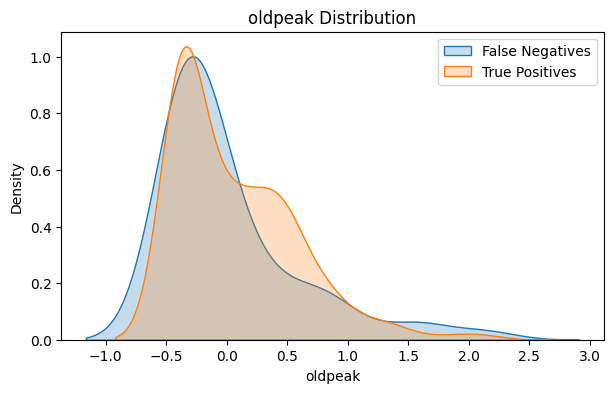

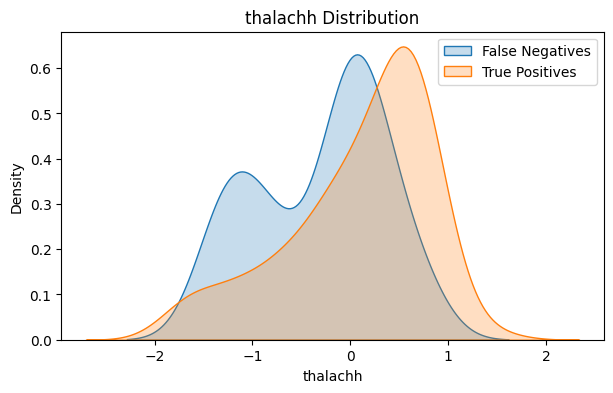

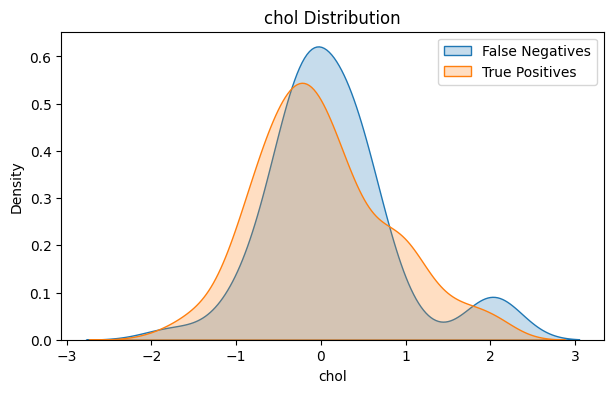

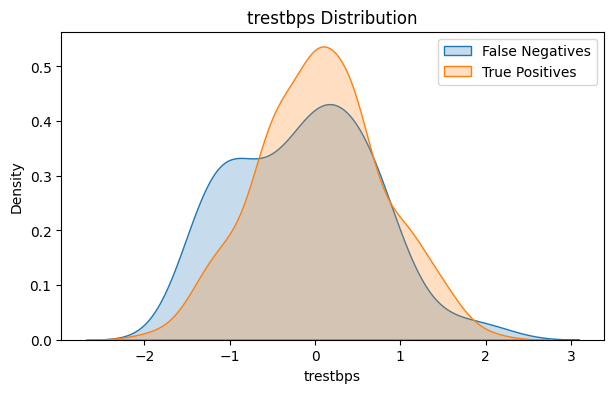

In [81]:

# VISUALIZE ERROR DISTRIBUTIONS
features = ['oldpeak', 'thalachh', 'chol', 'trestbps']

for col in features:

    plt.figure(figsize=(7,4))

    sns.kdeplot(
        false_negatives[col],
        label='False Negatives',
        fill=True
    )

    sns.kdeplot(
        true_positives[col],
        label='True Positives',
        fill=True
    )

    plt.title(f'{col} Distribution')

    plt.legend()

    plt.show()

In [82]:
# MISCLASSIFICATION RATE

misclassification_rate = (FP + FN) / (TP + TN + FP + FN)

print("Misclassification Rate:",
      round(misclassification_rate, 3))

Misclassification Rate: 0.211


In [83]:
# ERROR METRICS


false_positive_rate = FP / (FP + TN)

false_negative_rate = FN / (FN + TP)

print("False Positive Rate:",
      round(false_positive_rate, 3))

print("False Negative Rate:",
      round(false_negative_rate, 3))

False Positive Rate: 0.182
False Negative Rate: 0.24


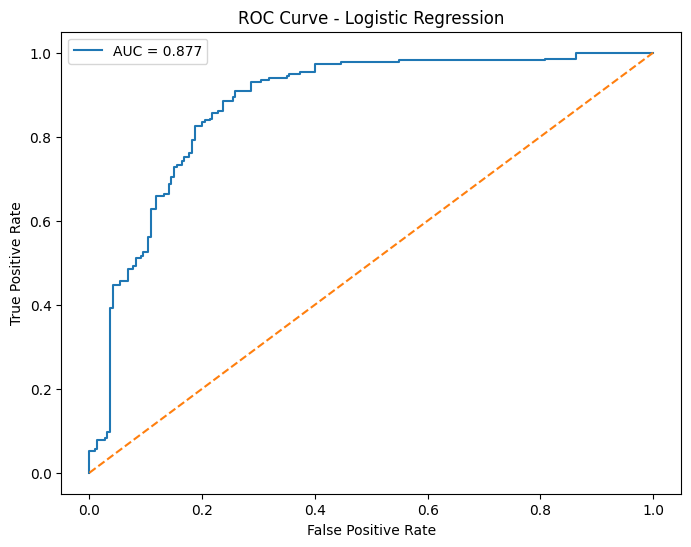

In [84]:
# ROC CURVE


from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

auc_score = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f'AUC = {auc_score:.3f}')

plt.plot([0,1], [0,1],
         linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()